# Credit Card Transaction Data Preparation
# # Project Background

Du nce intern in finance departmentship, credit-card transaction allocation required staff to manually search through multiple folio reco The. My original Python prototype was developed to test whether transactions could be located more efficiently using the last four card digits and transaction amount.

This portfolio project expands the original search prototype into a transaction allocation, reconciliation and analytics tool.

## Data Confidentiality

The original financial records cannot be shareite they msay contain sensitive customer and transaction information. Therefore, this project uses a completely synthetic dataset designed to resemble the structure of the original workflow without exposing real customer data.

## Objectives

The objectives of this project are to:

1. Generate a reproducible synthetic transaction dataset.
2. Assess the structure and quality of the raw data.
3. Clean and standardise inconsistent records.
4. Identify transactions that require manual review.
5. Analyse transaction patterns and operational KPIs.
6. Improve the original transaction-matching method.
7. Develop an interactive analytical application.

## Data Preparation

A synthetic dataset containing 2,000 original transactions was generated using Python. Intentional data-quality problems were introduced to simulate realistic operational data, including missing card information, invalid amounts, invalid dates, inconsistent payment labels and duplicate records.


In [1]:
import pandas as pd
from pathlib import Path

PROJECT_FOLDER = Path.cwd().parent

DATA_FOLDER = PROJECT_FOLDER / "data"

print("Project folder:", PROJECT_FOLDER)
print("Data folder:", DATA_FOLDER)

Project folder: C:\Users\U S E R\Credit-card-allocation-analytics
Data folder: C:\Users\U S E R\Credit-card-allocation-analytics\data


In [2]:
import numpy as np

# A fixed seed makes the generated data reproducible.
rng = np.random.default_rng(42)

# Number of synthetic transactions
number_of_transactions = 2000

# Generate synthetic transaction dates
transaction_dates = (
    pd.to_datetime("2025-01-01")
    + pd.to_timedelta(
        rng.integers(0, 90, number_of_transactions),
        unit="D"
    )
)

# Create the synthetic transaction dataset
raw_transactions = pd.DataFrame({
    "transaction_id": [
        f"TXN{i:06d}"
        for i in range(1, number_of_transactions + 1)
    ],
    "guest_name": [
        f"Guest {i:04d}"
        for i in rng.integers(1, 801, number_of_transactions)
    ],
    "room_no": rng.integers(
        101,
        800,
        number_of_transactions
    ),
    "folio_no": rng.integers(
        30000,
        40000,
        number_of_transactions
    ),
    "transaction_date": transaction_dates,
    "amount_rm": np.round(
        rng.lognormal(
            mean=6.1,
            sigma=0.55,
            size=number_of_transactions
        ),
        2
    ),
    "card_last4": [
        f"{number:04d}"
        for number in rng.integers(
            0,
            10000,
            number_of_transactions
        )
    ],
    "payment_method": rng.choice(
        ["Visa", "Mastercard", "American Express"],
        number_of_transactions,
        p=[0.45, 0.40, 0.15]
    ),
    "allocation_status": rng.choice(
        ["Matched", "Unmatched", "Pending"],
        number_of_transactions,
        p=[0.82, 0.10, 0.08]
    )
})

raw_transactions.head()

,transaction_id,guest_name,room_no,folio_no,transaction_date,amount_rm,card_last4,payment_method,allocation_status
0,TXN000001,Guest 0703,322,36191,2025-01-09,251.56,1503,Visa,Matched
1,TXN000002,Guest 0050,690,38292,2025-03-11,195.75,5450,Visa,Unmatched
2,TXN000003,Guest 0319,125,36401,2025-02-28,938.17,0546,Visa,Matched
3,TXN000004,Guest 0367,413,35940,2025-02-09,1689.77,8490,Visa,Unmatched
4,TXN000005,Guest 0639,660,34673,2025-02-08,343.21,7705,Visa,Pending


In [3]:
# Create a separate random generator for data-quality issues
rng_issues = np.random.default_rng(101)

# Preserve the original generated data
raw_data = raw_transactions.copy()

# Convert dates to text, as commonly found in CSV files
raw_data["transaction_date"] = (
    raw_data["transaction_date"].dt.strftime("%Y-%m-%d")
)

# 1. Add missing card information
missing_card_rows = rng_issues.choice(
    raw_data.index,
    size=20,
    replace=False
)

raw_data.loc[missing_card_rows, "card_last4"] = None

# 2. Add negative transaction amounts
negative_amount_rows = rng_issues.choice(
    raw_data.index,
    size=8,
    replace=False
)

raw_data.loc[negative_amount_rows, "amount_rm"] *= -1

# 3. Add inconsistent payment-method labels
payment_label_rows = rng_issues.choice(
    raw_data.index,
    size=25,
    replace=False
)

raw_data.loc[
    payment_label_rows,
    "payment_method"
] = "master card"

# 4. Add extra spaces to several guest names
name_space_rows = rng_issues.choice(
    raw_data.index,
    size=15,
    replace=False
)

raw_data.loc[
    name_space_rows,
    "guest_name"
] = "  " + raw_data.loc[
    name_space_rows,
    "guest_name"
] + "  "

# 5. Add invalid transaction dates
invalid_date_rows = rng_issues.choice(
    raw_data.index,
    size=5,
    replace=False
)

raw_data.loc[
    invalid_date_rows,
    "transaction_date"
] = "invalid-date"

# 6. Add duplicate transaction records
duplicate_rows = raw_data.sample(
    n=15,
    random_state=42
)

raw_data = pd.concat(
    [raw_data, duplicate_rows],
    ignore_index=True
)

# Shuffle the row order
raw_data = raw_data.sample(
    frac=1,
    random_state=42
).reset_index(drop=True)

# Save the messy dataset
raw_file = DATA_FOLDER / "raw_transactions.csv"

raw_data.to_csv(
    raw_file,
    index=False
)

print("Dataset saved successfully.")
print("File location:", raw_file)
print("Rows:", raw_data.shape[0])
print("Columns:", raw_data.shape[1])

raw_data.head()

Dataset saved successfully.
File location: C:\Users\U S E R\Credit-card-allocation-analytics\data\raw_transactions.csv
Rows: 2015
Columns: 9


,transaction_id,guest_name,room_no,folio_no,transaction_date,amount_rm,card_last4,payment_method,allocation_status
0,TXN001199,Guest 0784,498,32386,2025-03-14,727.43,7421,Visa,Pending
1,TXN000527,Guest 0375,114,30144,2025-03-25,1273.31,1389,Visa,Matched
2,TXN000394,Guest 0177,148,35550,2025-02-23,814.75,9635,Visa,Matched
3,TXN001408,Guest 0511,668,36843,2025-03-20,804.24,4383,Mastercard,Matched
4,TXN000434,Guest 0252,180,33548,2025-01-12,826.32,8010,Visa,Matched


In [4]:
# Load the raw dataset from the CSV file
transactions = pd.read_csv(
    raw_file,
    dtype={"card_last4": "string"}
)

# Create a data-quality summary
data_profile = pd.DataFrame({
    "data_type": transactions.dtypes.astype(str),
    "missing_values": transactions.isna().sum(),
    "unique_values": transactions.nunique()
})

print("DATASET OVERVIEW")
print("----------------")
print("Number of rows:", transactions.shape[0])
print("Number of columns:", transactions.shape[1])
print("Duplicate rows:", transactions.duplicated().sum())

print("\nDATA QUALITY SUMMARY")
display(data_profile)

print("\nFIRST FIVE ROWS")
display(transactions.head())

DATASET OVERVIEW
----------------
Number of rows: 2015
Number of columns: 9
Duplicate rows: 15

DATA QUALITY SUMMARY


,data_type,missing_values,unique_values
transaction_id,object,0,2000
guest_name,object,0,756
room_no,int64,0,661
folio_no,int64,0,1819
transaction_date,object,0,91
amount_rm,float64,0,1974
card_last4,string,20,1790
payment_method,object,0,4
allocation_status,object,0,3



FIRST FIVE ROWS


,transaction_id,guest_name,room_no,folio_no,transaction_date,amount_rm,card_last4,payment_method,allocation_status
0,TXN001199,Guest 0784,498,32386,2025-03-14,727.43,7421,Visa,Pending
1,TXN000527,Guest 0375,114,30144,2025-03-25,1273.31,1389,Visa,Matched
2,TXN000394,Guest 0177,148,35550,2025-02-23,814.75,9635,Visa,Matched
3,TXN001408,Guest 0511,668,36843,2025-03-20,804.24,4383,Mastercard,Matched
4,TXN000434,Guest 0252,180,33548,2025-01-12,826.32,8010,Visa,Matched


In [5]:
# Create a copy so the original raw dataset remains unchanged
clean_data = transactions.copy()

# Count and remove complete duplicate rows
duplicates_removed = clean_data.duplicated().sum()
clean_data = clean_data.drop_duplicates().copy()

# Remove unnecessary spaces from guest names
clean_data["guest_name"] = (
    clean_data["guest_name"]
    .str.strip()
)

# Standardise payment-method labels
clean_data["payment_method"] = (
    clean_data["payment_method"]
    .str.strip()
    .str.lower()
    .replace({
        "master card": "mastercard"
    })
    .str.title()
)

# Standardise allocation-status labels
clean_data["allocation_status"] = (
    clean_data["allocation_status"]
    .str.strip()
    .str.lower()
    .str.title()
)

# Convert transaction dates into proper datetime values
# Invalid dates will become NaT (Not a Time)
clean_data["transaction_date"] = pd.to_datetime(
    clean_data["transaction_date"],
    errors="coerce"
)

# Ensure transaction amounts are numeric
clean_data["amount_rm"] = pd.to_numeric(
    clean_data["amount_rm"],
    errors="coerce"
)

# Standardise card digits as text
clean_data["card_last4"] = (
    clean_data["card_last4"]
    .str.strip()
)

# Create data-quality flags
clean_data["missing_card"] = (
    clean_data["card_last4"].isna()
)

clean_data["invalid_amount"] = (
    clean_data["amount_rm"].isna() |
    (clean_data["amount_rm"] <= 0)
)

clean_data["invalid_date"] = (
    clean_data["transaction_date"].isna()
)

# Give each transaction an overall quality status
quality_columns = [
    "missing_card",
    "invalid_amount",
    "invalid_date"
]

clean_data["data_quality_status"] = np.where(
    clean_data[quality_columns].any(axis=1),
    "Review Required",
    "Valid"
)

# Display the cleaning results
print("CLEANING SUMMARY")
print("----------------")
print("Original rows:", len(transactions))
print("Duplicates removed:", duplicates_removed)
print("Remaining rows:", len(clean_data))
print("Missing card values:", clean_data["missing_card"].sum())
print("Invalid amounts:", clean_data["invalid_amount"].sum())
print("Invalid dates:", clean_data["invalid_date"].sum())

print("\nSTANDARDISED PAYMENT METHODS")
print(clean_data["payment_method"].value_counts())

print("\nDATA QUALITY STATUS")
print(clean_data["data_quality_status"].value_counts())

CLEANING SUMMARY
----------------
Original rows: 2015
Duplicates removed: 15
Remaining rows: 2000
Missing card values: 20
Invalid amounts: 8
Invalid dates: 5

STANDARDISED PAYMENT METHODS
payment_method
Visa                895
Mastercard          800
American Express    305
Name: count, dtype: int64

DATA QUALITY STATUS
data_quality_status
Valid              1967
Review Required      33
Name: count, dtype: int64


## Data Cleaning and Validation

Before conducting analysis, the raw data was inspected for duplicate records, missing values, invalid data types and inconsistent category labels.

The following cleaning steps were performed:

* Removed complete duplicate rows.
* Removed unnecessary spaces from guest names.
* Standardised payment-method and allocation-status labels.
* Converted transaction dates into datetime values.
* Ensured transaction amounts were stored numerically.
* Created flags for missing card values, invalid amounts and invalid dates.
* Classified records as either `Valid` or `Review Required`.

Problematic transactions were retained for investigation instead of being silently deleted.

### Initial Findings

* Raw records: 2,015
* Duplicate records removed: 15
* Remaining records: 2,000
* Valid records: 1,967
* Records requiring review: 33
* Data-quality exception rate: 1.65%



In [6]:
# Separate valid transactions from records requiring investigation
valid_transactions = clean_data[
    clean_data["data_quality_status"] == "Valid"
].copy()

review_transactions = clean_data[
    clean_data["data_quality_status"] == "Review Required"
].copy()

# Create output file locations
processed_file = DATA_FOLDER / "processed_transactions.csv"
valid_file = DATA_FOLDER / "valid_transactions.csv"
review_file = DATA_FOLDER / "transactions_for_review.csv"

# Save the processed datasets
clean_data.to_csv(
    processed_file,
    index=False,
    date_format="%Y-%m-%d"
)

valid_transactions.to_csv(
    valid_file,
    index=False,
    date_format="%Y-%m-%d"
)

review_transactions.to_csv(
    review_file,
    index=False,
    date_format="%Y-%m-%d"
)

# Calculate the data-quality exception rate
exception_rate = (
    len(review_transactions) /
    len(clean_data) *
    100
)

print("FILES SAVED SUCCESSFULLY")
print("------------------------")
print("All processed records:", len(clean_data))
print("Valid records:", len(valid_transactions))
print("Records requiring review:", len(review_transactions))
print(f"Data-quality exception rate: {exception_rate:.2f}%")

print("\nRECORDS REQUIRING REVIEW")
display(
    review_transactions[
        [
            "transaction_id",
            "transaction_date",
            "amount_rm",
            "card_last4",
            "missing_card",
            "invalid_amount",
            "invalid_date"
        ]
    ].head(10)
)

FILES SAVED SUCCESSFULLY
------------------------
All processed records: 2000
Valid records: 1967
Records requiring review: 33
Data-quality exception rate: 1.65%

RECORDS REQUIRING REVIEW


,transaction_id,transaction_date,amount_rm,card_last4,missing_card,invalid_amount,invalid_date
25,TXN001299,NaT,198.68,9145,False,False,True
154,TXN000615,2025-03-03,413.30,<NA>,True,False,False
336,TXN000586,2025-03-25,261.54,<NA>,True,False,False
345,TXN001212,2025-03-12,-638.86,5997,False,True,False
377,TXN000068,2025-02-03,-524.72,0957,False,True,False
442,TXN000728,2025-01-08,230.52,<NA>,True,False,False
521,TXN001546,2025-02-23,253.08,<NA>,True,False,False
575,TXN001176,2025-01-31,394.87,<NA>,True,False,False
659,TXN000119,2025-01-23,-312.90,6165,False,True,False
691,TXN001233,2025-03-29,403.37,<NA>,True,False,False



## Preparing Analysis and Review Datasets

After cleaning, the transactions were separated according to their data-quality status.

Valid transactions will be used for KPI calculations and exploratory analysis. Transactions containing missing or invalid information will be exported separately for further investigation. exception rate: 1.65%


In [7]:
# Separate valid transactions from records requiring investigation
valid_transactions = clean_data[
    clean_data["data_quality_status"] == "Valid"
].copy()

review_transactions = clean_data[
    clean_data["data_quality_status"] == "Review Required"
].copy()

# Create file locations
processed_file = DATA_FOLDER / "processed_transactions.csv"
valid_file = DATA_FOLDER / "valid_transactions.csv"
review_file = DATA_FOLDER / "transactions_for_review.csv"

# Save the datasets
clean_data.to_csv(
    processed_file,
    index=False,
    date_format="%Y-%m-%d"
)

valid_transactions.to_csv(
    valid_file,
    index=False,
    date_format="%Y-%m-%d"
)

review_transactions.to_csv(
    review_file,
    index=False,
    date_format="%Y-%m-%d"
)

# Calculate the exception rate
exception_rate = (
    len(review_transactions) /
    len(clean_data) *
    100
)

print("FILES SAVED SUCCESSFULLY")
print("------------------------")
print("All processed records:", len(clean_data))
print("Valid records:", len(valid_transactions))
print("Records requiring review:", len(review_transactions))
print(f"Data-quality exception rate: {exception_rate:.2f}%")

print("\nSAMPLE RECORDS REQUIRING REVIEW")

display(
    review_transactions[
        [
            "transaction_id",
            "transaction_date",
            "amount_rm",
            "card_last4",
            "missing_card",
            "invalid_amount",
            "invalid_date"
        ]
    ].head(10)
)

FILES SAVED SUCCESSFULLY
------------------------
All processed records: 2000
Valid records: 1967
Records requiring review: 33
Data-quality exception rate: 1.65%

SAMPLE RECORDS REQUIRING REVIEW


,transaction_id,transaction_date,amount_rm,card_last4,missing_card,invalid_amount,invalid_date
25,TXN001299,NaT,198.68,9145,False,False,True
154,TXN000615,2025-03-03,413.30,<NA>,True,False,False
336,TXN000586,2025-03-25,261.54,<NA>,True,False,False
345,TXN001212,2025-03-12,-638.86,5997,False,True,False
377,TXN000068,2025-02-03,-524.72,0957,False,True,False
442,TXN000728,2025-01-08,230.52,<NA>,True,False,False
521,TXN001546,2025-02-23,253.08,<NA>,True,False,False
575,TXN001176,2025-01-31,394.87,<NA>,True,False,False
659,TXN000119,2025-01-23,-312.90,6165,False,True,False
691,TXN001233,2025-03-29,403.37,<NA>,True,False,False


## Exploratory Data Analysis

Only transactions classified as `Valid` are used for the main analysis. This prevents invalid amounts, dates, or missing card information from distorting the business results.

### Key Performance Indicators

The first stage calculates the total transaction volume, transaction value, average and median amounts, and allocation performance.

In [8]:
# Calculate transaction KPIs using valid records only
total_transactions = len(valid_transactions)

total_value = valid_transactions["amount_rm"].sum()

average_value = valid_transactions["amount_rm"].mean()

median_value = valid_transactions["amount_rm"].median()

matched_transactions = (
    valid_transactions["allocation_status"]
    .eq("Matched")
    .sum()
)

unmatched_transactions = (
    valid_transactions["allocation_status"]
    .eq("Unmatched")
    .sum()
)

pending_transactions = (
    valid_transactions["allocation_status"]
    .eq("Pending")
    .sum()
)

allocation_rate = (
    matched_transactions /
    total_transactions *
    100
)

# Display the KPI results
print("TRANSACTION KPI SUMMARY")
print("-----------------------")
print(f"Total valid transactions: {total_transactions:,}")
print(f"Total transaction value: RM {total_value:,.2f}")
print(f"Average transaction value: RM {average_value:,.2f}")
print(f"Median transaction value: RM {median_value:,.2f}")
print(f"Matched transactions: {matched_transactions:,}")
print(f"Unmatched transactions: {unmatched_transactions:,}")
print(f"Pending transactions: {pending_transactions:,}")
print(f"Allocation rate: {allocation_rate:.2f}%")

TRANSACTION KPI SUMMARY
-----------------------
Total valid transactions: 1,967
Total transaction value: RM 1,027,427.04
Average transaction value: RM 522.33
Median transaction value: RM 450.87
Matched transactions: 1,619
Unmatched transactions: 177
Pending transactions: 171
Allocation rate: 82.31%


### KPI Findings

The valid dataset contains 1,967 transactions with a combined value of RM1,027,427.04.

The average transaction value is RM522.33, while the median is RM450.87. The higher average suggests that several high-value transactions may be increasing the overall mean.

A total of 1,619 transactions were successfully matched, resulting in an allocation rate of 82.31%.

However, 177 transactions remained unmatched and another 171 were pending. Combined, 348 transactions, or 17.69% of valid records, had not been fully allocated. These transactions represent the main area requiring further operational attention.

The next stage will examine transaction patterns by allocation status, payment method and date to understand where unresolved transactions are concentrated.


## Transaction Allocation Status

This visualisation compares the number of matched, unmatched and pending transaction. It helps identify the proportion of transaction that have not been fully allocated and may require operational follow up

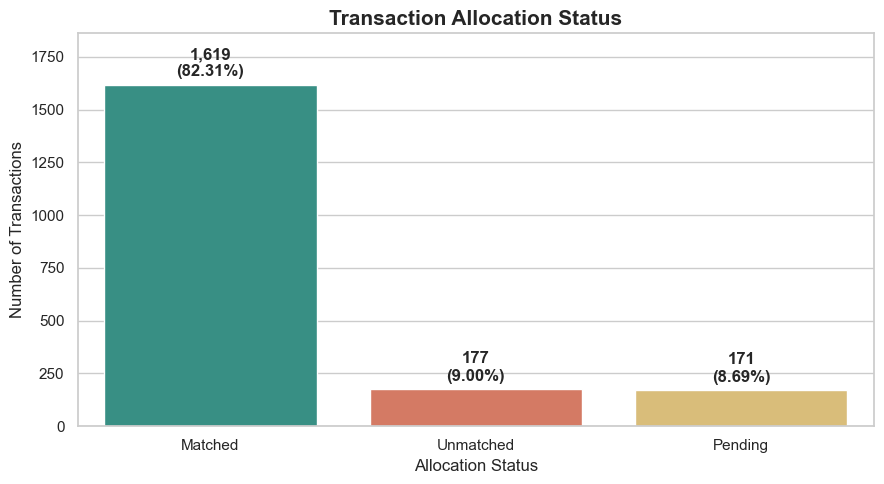

,allocation_status,transaction_count,percentage
0,Matched,1619,82.308083
1,Unmatched,177,8.998475
2,Pending,171,8.693442


In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set the visual style
sns.set_theme(style="whitegrid")

# Arrange the statuses in a logical order
status_order = ["Matched", "Unmatched", "Pending"]

# Calculate transaction counts and percentages
status_summary = (
    valid_transactions["allocation_status"]
    .value_counts()
    .reindex(status_order)
    .reset_index()
)

status_summary.columns = [
    "allocation_status",
    "transaction_count"
]

status_summary["percentage"] = (
    status_summary["transaction_count"]
    / status_summary["transaction_count"].sum()
    * 100
)

# Create the bar chart
plt.figure(figsize=(9, 5))

ax = sns.barplot(
    data=status_summary,
    x="allocation_status",
    y="transaction_count",
    order=status_order,
    palette=[
        "#2A9D8F",  # Matched
        "#E76F51",  # Unmatched
        "#E9C46A"   # Pending
    ]
)

# Add count and percentage labels above each bar
for bar, count, percentage in zip(
    ax.patches,
    status_summary["transaction_count"],
    status_summary["percentage"]
):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 25,
        f"{count:,}\n({percentage:.2f}%)",
        ha="center",
        va="bottom",
        fontweight="bold"
    )

plt.title(
    "Transaction Allocation Status",
    fontsize=15,
    fontweight="bold"
)
plt.xlabel("Allocation Status")
plt.ylabel("Number of Transactions")
plt.ylim(
    0,
    status_summary["transaction_count"].max() * 1.15
)
plt.tight_layout()
plt.show()

status_summary

### Allocation Perfomance by Payment Method

This analysis compares transaction outcomes across Visa, Mastercard and America Express. The unresolved rate is calculated for each payment method to determine whether any method has a disproportionately high number of unmatched or pending transaction

In [11]:
# Summarise allocation status by payment method
payment_summary = pd.crosstab(
    valid_transactions["payment_method"],
    valid_transactions["allocation_status"]
)

# Ensure all required status columns are present
payment_summary = payment_summary.reindex(
    columns=["Matched", "Unmatched", "Pending"],
    fill_value=0
)

# Calculate totals and unresolved transactions
payment_summary["Total"] = payment_summary.sum(axis=1)

payment_summary["Unresolved"] = (
    payment_summary["Unmatched"]
    + payment_summary["Pending"]
)

payment_summary["Unresolved Rate (%)"] = (
    payment_summary["Unresolved"]
    / payment_summary["Total"]
    * 100
)

# Arrange from highest to lowest unresolved rate
payment_summary = payment_summary.sort_values(
    "Unresolved Rate (%)",
    ascending=False
)

display(
    payment_summary.style.format({
        "Unresolved Rate (%)": "{:.2f}%"
    })
)

allocation_status,Matched,Unmatched,Pending,Total,Unresolved,Unresolved Rate (%)
payment_method,,,,,,
Mastercard,638,77,68,783,145,18.52%
Visa,728,73,81,882,154,17.46%
American Express,253,27,22,302,49,16.23%


#### Interpretation Limitation

Mastercard recorded the highest simulated unresolved rate at 18.52%, followed by Visa at 17.46% and American Express at 16.23%.

However, payment methods and allocation statuses were synthetically generated and were not designed with a causal relationship. Therefore, these results demonstrate the analytical method but should not be interpreted as evidence that a particular payment method creates allocation problems in real hotel operations.